# Módulo 1: Fundamentos de NLP y Preprocesamiento de Texto

Una revisión conceptual del ecosistema NLP y las técnicas básicas de preprocesamiento.

## 1.1 Introducción al NLP y NLU

### ¿Qué es el Procesamiento de Lenguaje Natural?

El **NLP (Natural Language Processing)** es la rama de la IA que estudia cómo las máquinas pueden **entender, interpretar y generar** lenguaje humano.

| Sigla | Nombre | ¿Qué hace? | Ejemplo |
|-------|--------|------------|---------|
| **NLP** | Natural Language Processing | Paraguas general: limpiar, representar y procesar texto | Tokenización, POS tagging, NER |
| **NLU** | Natural Language Understanding | Extraer *significado* del texto | Clasificar intención, responder preguntas |
| **NLG** | Natural Language Generation | Producir texto coherente | Resúmenes, chatbots, traducción |

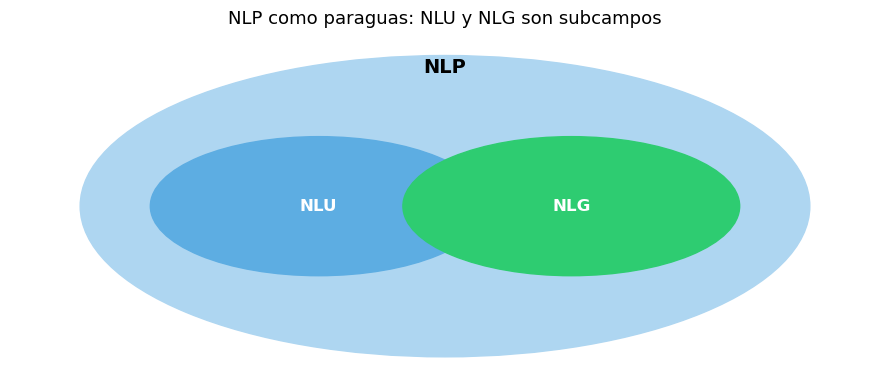

### Casos de uso comunes

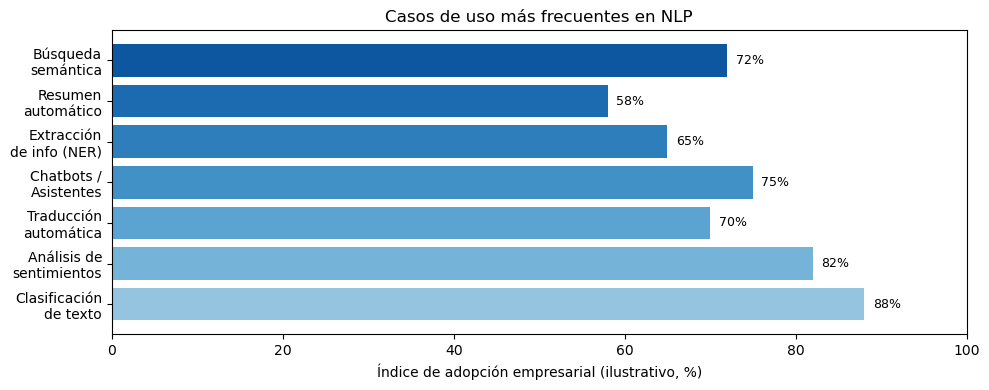

### Ecosistema de NLP en Python

```
Preprocesamiento  │  NLTK · spaCy · regex
Vectorización     │  scikit-learn (TF-IDF, BoW)
Embeddings        │  gensim (Word2Vec) · GloVe · FastText
Deep Learning     │  PyTorch · TensorFlow
Transformers      │  Hugging Face transformers / datasets
LLMs              │  OpenAI API · Anthropic API · Ollama (local)
```

---
## 1.2 Preprocesamiento de Texto

El **pipeline de preprocesamiento** convierte texto crudo en representaciones limpias y normalizadas que los modelos pueden consumir.

### Tokenización

In [3]:
import re

texto = "Hello, world! NLP is great—isn't it? #Python @huggingface"

# 1. Tokenización ingenua (split por espacios)
tokens_naive = texto.split()
print("Naive split:   ", tokens_naive)

# 2. Tokenización con regex
tokens_re = re.findall(r"\b\w+\b", texto)
print("Regex tokens:  ", tokens_re)

# 3. Tokenización de subpalabras (simulada)
# Los tokenizadores BPE dividen palabras poco frecuentes en sub-unidades
ejemplo_bpe = {"unhappiness": ["un", "##happi", "##ness"],
               "tokenization": ["token", "##ization"]}
print("\nEjemplo BPE (como BERT):")
for word, parts in ejemplo_bpe.items():
    print(f"  {word:15} → {parts}")

Naive split:    ['Hello,', 'world!', 'NLP', 'is', "great—isn't", 'it?', '#Python', '@huggingface']
Regex tokens:   ['Hello', 'world', 'NLP', 'is', 'great', 'isn', 't', 'it', 'Python', 'huggingface']

Ejemplo BPE (como BERT):
  unhappiness     → ['un', '##happi', '##ness']
  tokenization    → ['token', '##ization']


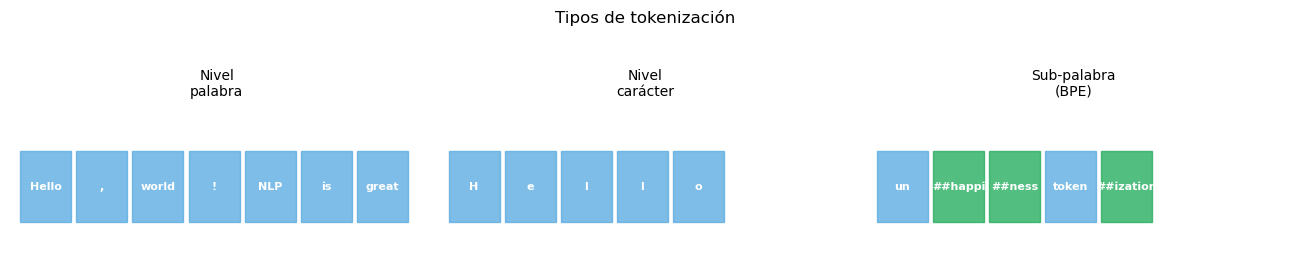

### Eliminación de stopwords y puntuación

In [5]:
# Stopwords: palabras muy frecuentes con poco valor semántico
STOPWORDS = {"the", "a", "an", "is", "it", "in", "on", "at", "to", "of", "and", "or", "but", "not", "this", "that"}

def remove_stopwords_punct(tokens):
    return [t for t in tokens if t.isalpha() and t.lower() not in STOPWORDS]

frase = "The quick brown fox is jumping over the lazy dog and it's not stopping"
tokens_orig = frase.lower().split()
tokens_clean = remove_stopwords_punct(tokens_orig)

print(f"Original  ({len(tokens_orig)} tokens): {tokens_orig}")
print(f"Limpio    ({len(tokens_clean)} tokens): {tokens_clean}")
print(f"Reducción: {(1 - len(tokens_clean)/len(tokens_orig))*100:.0f}%")

Original  (14 tokens): ['the', 'quick', 'brown', 'fox', 'is', 'jumping', 'over', 'the', 'lazy', 'dog', 'and', "it's", 'not', 'stopping']
Limpio    (8 tokens): ['quick', 'brown', 'fox', 'jumping', 'over', 'lazy', 'dog', 'stopping']
Reducción: 43%


### Normalización: Stemming vs Lematización

In [6]:
# Diferencia conceptual entre stemming y lematización
# Stemming: corta el sufijo (rápido, pero puede generar raíces no reales)
# Lematización: usa diccionario para encontrar la forma canónica

ejemplos = [
    ("running",   "run",     "run"),
    ("studies",   "studi",   "study"),
    ("better",    "better",  "good"),
    ("wolves",    "wolv",    "wolf"),
    ("caring",    "care",    "care"),
    ("happily",   "happili", "happily"),
]

print(f"{'Palabra':<12} {'Stem (Porter)':<15} {'Lema (spaCy)':<15}")
print("-" * 45)
for word, stem, lemma in ejemplos:
    print(f"{word:<12} {stem:<15} {lemma:<15}")

Palabra      Stem (Porter)   Lema (spaCy)   
---------------------------------------------
running      run             run            
studies      studi           study          
better       better          good           
wolves       wolv            wolf           
caring       care            care           
happily      happili         happily        


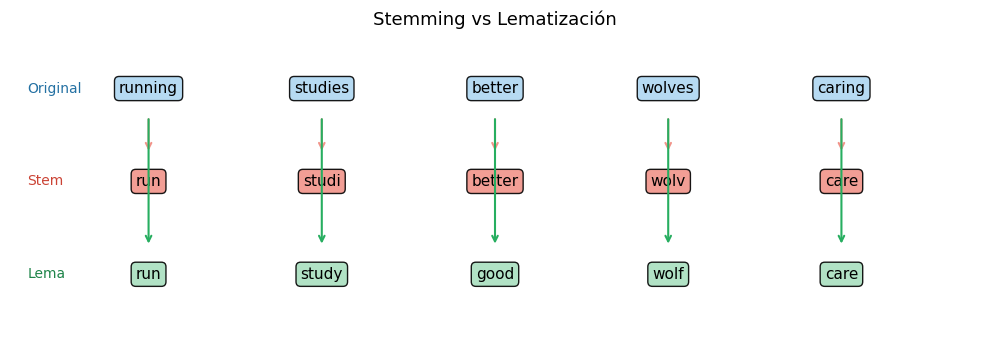

### Expresiones Regulares

In [8]:
import re

tweet = "Just bought the @Apple iPhone16 for $999!! Check: https://apple.com #Tech #NLP 😃"

patrones = {
    "URLs":       re.compile(r'https?://\S+|www\.\S+'),
    "Menciones":  re.compile(r'@\w+'),
    "Hashtags":   re.compile(r'#(\w+)'),
    "Precios":    re.compile(r'\$[\d,]+'),
    "Solo texto": re.compile(r'[^a-zA-Z\s]'),
}

print(f"Tweet: {tweet}\n")
for nombre, patron in list(patrones.items())[:-1]:
    encontrado = patron.findall(tweet)
    print(f"{nombre:<12}: {encontrado}")

texto_limpio = patrones["Solo texto"].sub('', tweet).strip()
print(f"\nSolo texto  : '{texto_limpio.strip()}'")

Tweet: Just bought the @Apple iPhone16 for $999!! Check: https://apple.com #Tech #NLP 😃

URLs        : ['https://apple.com']
Menciones   : ['@Apple']
Hashtags    : ['Tech', 'NLP']
Precios     : ['$999']

Solo texto  : 'Just bought the Apple iPhone for  Check httpsapplecom Tech NLP'


### Pipeline completo de preprocesamiento

In [9]:
import re

STOPWORDS = {"the", "a", "an", "is", "it", "in", "on", "at", "to",
             "of", "and", "or", "but", "not", "this", "that", "was", "for"}

# Lematización simplificada (reglas básicas para demo)
LEMMA_MAP = {"running": "run", "better": "good", "studies": "study",
             "loved": "love", "amazing": "amazing", "products": "product"}

def pipeline_preprocesamiento(texto: str) -> list:
    # 1. Minúsculas
    texto = texto.lower()
    # 2. Eliminar URLs y menciones
    texto = re.sub(r'https?://\S+|@\w+|#\w+', ' ', texto)
    # 3. Eliminar puntuación y caracteres especiales
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    # 4. Tokenizar
    tokens = texto.split()
    # 5. Eliminar stopwords
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    # 6. Lematizar
    tokens = [LEMMA_MAP.get(t, t) for t in tokens]
    return tokens

textos = [
    "The product is amazing! I've been running it for 3 days and it's better than expected.",
    "@Amazon studies show that this item was loved by customers! #Tech",
]

for t in textos:
    tokens = pipeline_preprocesamiento(t)
    print(f"Entrada : {t}")
    print(f"Salida  : {tokens}\n")

Entrada : The product is amazing! I've been running it for 3 days and it's better than expected.
Salida  : ['product', 'amazing', 've', 'been', 'run', 'days', 'good', 'than', 'expected']

Entrada : @Amazon studies show that this item was loved by customers! #Tech
Salida  : ['study', 'show', 'item', 'love', 'by', 'customers']



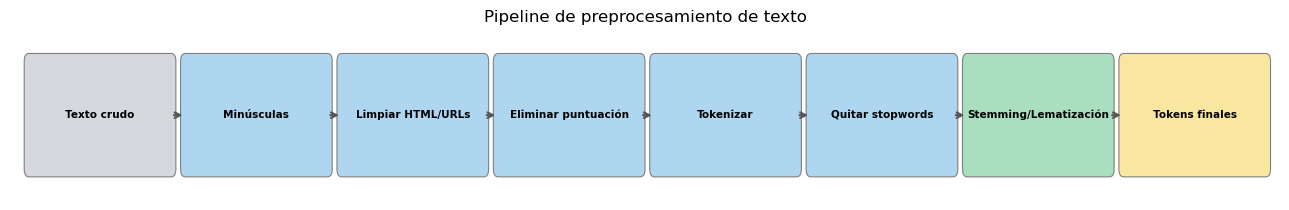

---
## Resumen del Módulo 1

| Concepto | Cuándo usarlo |
|----------|---------------|
| **Tokenización por palabras** | Textos estándar, modelos clásicos |
| **Tokenización sub-palabra (BPE)** | Transformers (BERT, GPT) |
| **Stopwords** | Eliminar cuando importa el *tema*, no la sintaxis |
| **Stemming** | Rápido, sin diccionario, tolera errores de raíz |
| **Lematización** | Más preciso, necesita diccionario (spaCy, NLTK) |
| **Regex** | Patrones estructurados: URLs, emails, precios |